<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Neural_Networks/Digit_Classification_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
# Getting the data
from sklearn.datasets import load_digits

In [ ]:
# Data Representation
data = load_digits() #Store data in variable 'data'
X = data.data # Input variable
Y = data.target # Output Variable
df = pd.DataFrame(X) # the values of X
df['target'] = Y #  values of Y
print(df.head()) # print the dataset
print(df.describe()) #gives description
set(Y) # Unique Lables

print("X shape:" , X.shape)
print("Y shape:" , Y.shape)
print("DataFrame shape:", df.shape)
df


     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]
            0            1            2            3            4  \
count  1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean      0.0     0.303840     5.204786    11.835838    11.848080   
std       0.0     0.907192     

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


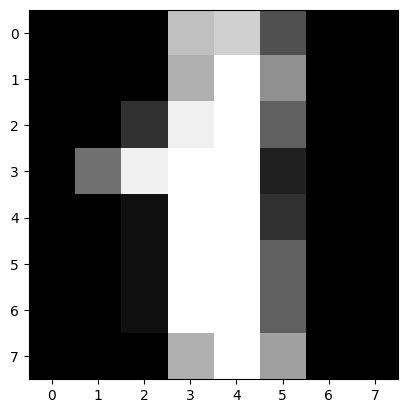

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(data.images[1], cmap='gray')
plt.show()

In [ ]:
# Normilizing the data  (Pixel value range 0 to 16)
X = X / 16  # Values range 0 to 1

# One-hot encode labels (Each position = One class)
def one_hot_encode(Y):                     #0 = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        return np.eye(10)[Y]               #1 = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
                                           #3 = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# np.eye(n) creates an identity matrix
Y = one_hot_encode(Y)
print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (1797, 64)
Y shape: (1797, 10)


In [ ]:
# Initialization Parameters
np.random.seed(42)  #It controls randomness

w1 = np.random.randn(64, 128) * np.sqrt(2/64)    # np.random.randn() generates random numbers and * 0.1 makes values very small.
b1 = np.zeros((1, 128)) #One bias per neuron.

w2 = np.random.randn(128, 64) * np.sqrt(2/128)
b2 = np.zeros((1, 64))

w3 = np.random.randn(64, 10) * np.sqrt(2/64)
b3 = np.zeros((1, 10))

In [ ]:
# Activation Functions
def relu(Z):
  return np.maximum(0, Z)   # Removes negatives values

def softmax(Z):    # Converts output into probabilities
  expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True)) #Stable

  return expZ / np.sum(expZ, axis=1, keepdims=True)

print(w1.shape, b1.shape)
print(w2.shape, b2.shape)
print(w3.shape, b3.shape)


(64, 128) (1, 128)
(128, 64) (1, 64)
(64, 10) (1, 10)


In [ ]:
# Forward Propagation
def forward(X):
  #Layer1
  Z1 = np.dot(X, w1) + b1
  A1 = relu(Z1)

  #Layer2
  Z2 = np.dot(A1, w2) + b2
  A2 = relu(Z2)

  #Output Layer
  Z3 = np.dot(A2, w3) + b3
  A3 = softmax(Z3)

  return Z1, A1, Z2, A2, Z3, A3

Z1, A1, Z2, A2, Z3, A3 = forward(X)
print("Output shape: " , A3.shape)

Output shape:  (1797, 10)


In [ ]:
# Cross-Entropy Loss (For multi-class)
def compute_loss(Y_true, Y_pred):
  m = Y_true.shape[0]   # number of samples
  #avoid log(0)
  Y_pred = np.clip(Y_pred, 1e-10, 1 - 1e-10)
  loss = -np.sum(Y_true * np.log(Y_pred)) / m
  return loss

loss = compute_loss(Y, A3)
print("Loss:", loss)

Loss: 2.4055465841796124


In [ ]:
# Backpropagation

def backward(X, y, Z1, A1, Z2, A2, Z3, A3):
    m = X.shape[0]

    # Output layer
    dZ3 = A3 - Y
    dw3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Layer 2
    dA2 = dZ3 @ w3.T
    dZ2 = dA2 * (Z2 > 0)
    dw2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Layer 1
    dA1 = dZ2 @ w2.T
    dZ1 = dA1 * (Z1 > 0)
    dw1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dw1, db1, dw2, db2, dw3, db3

In [ ]:
def update_params(dw1, db1, dw2, db2, dw3, db3, lr):
    global w1, b1, w2, b2, w3, b3

    w1 -= lr * dw1
    b1 -= lr * db1

    w2 -= lr * dw2
    b2 -= lr * db2

    w3 -= lr * dw3
    b3 -= lr * db3

epochs = 5000
learning_rate = 0.01

for i in range(epochs):

    # Forward
    Z1, A1, Z2, A2, Z3, A3 = forward(X)

    # Loss
    loss = compute_loss(Y, A3)

    # Backprop
    dw1, db1, dw2, db2, dw3, db3 = backward(X, Y, Z1, A1, Z2, A2, Z3, A3)

    # Update
    update_params(dw1, db1, dw2, db2, dw3, db3, learning_rate)

    # Print progress
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")



Epoch 0, Loss: 2.4055465841796124
Epoch 100, Loss: 1.842671407946522
Epoch 200, Loss: 1.3974438566129737
Epoch 300, Loss: 0.9929429120004938
Epoch 400, Loss: 0.7208459020646875
Epoch 500, Loss: 0.5564873060229261
Epoch 600, Loss: 0.45305970680101015
Epoch 700, Loss: 0.38284740659979727
Epoch 800, Loss: 0.33341462863190496
Epoch 900, Loss: 0.2965645824051492
Epoch 1000, Loss: 0.2679329861205469
Epoch 1100, Loss: 0.24502973629695765
Epoch 1200, Loss: 0.22618370382457426
Epoch 1300, Loss: 0.21035183783850928
Epoch 1400, Loss: 0.19693282645977608
Epoch 1500, Loss: 0.18539581721388865
Epoch 1600, Loss: 0.17528902434762578
Epoch 1700, Loss: 0.16636152634217963
Epoch 1800, Loss: 0.15831364806519221
Epoch 1900, Loss: 0.15113222438821045
Epoch 2000, Loss: 0.14465561107163474
Epoch 2100, Loss: 0.13877465785814733
Epoch 2200, Loss: 0.13338436763732053
Epoch 2300, Loss: 0.12845925926889054
Epoch 2400, Loss: 0.12392402046355201
Epoch 2500, Loss: 0.11974951354757055
Epoch 2600, Loss: 0.1158678455184

In [ ]:
predictions = np.argmax(A3, axis=1)
true_labels = np.argmax(Y, axis=1)

accuracy = np.mean(predictions == true_labels)
print("Accuracy:", accuracy)

Accuracy: 0.9905397885364496
